In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:

df = pd.read_csv("../datasets/comprar_alquilar.csv")

print("Dimensiones del dataset:", df.shape)

print("\nPrimeras filas:")
display(df.head())

print("\nInformación del dataset:")
df.info()

Dimensiones del dataset: (202, 10)

Primeras filas:


,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1



Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ingresos        202 non-null    int64
 1   gastos_comunes  202 non-null    int64
 2   pago_coche      202 non-null    int64
 3   gastos_otros    202 non-null    int64
 4   ahorros         202 non-null    int64
 5   vivienda        202 non-null    int64
 6   estado_civil    202 non-null    int64
 7   hijos           202 non-null    int64
 8   trabajo         202 non-null    int64
 9   comprar         202 non-null    int64
dtypes: int64(10)
memory usage: 15.9 KB


In [4]:
print("Valores faltantes:")
print(df.isnull().sum())

print("\nFilas duplicadas:")
print(df.duplicated().sum())

Valores faltantes:
ingresos          0
gastos_comunes    0
pago_coche        0
gastos_otros      0
ahorros           0
vivienda          0
estado_civil      0
hijos             0
trabajo           0
comprar           0
dtype: int64

Filas duplicadas:
0


In [5]:
print(df.describe())

          ingresos  gastos_comunes  pago_coche  gastos_otros       ahorros  \
count   202.000000      202.000000  202.000000    202.000000    202.000000   
mean   4958.995050      971.584158  211.742574    515.425743  38749.668317   
std    1682.862556      272.106351  124.940754    168.103075  17365.231870   
min    2008.000000      384.000000    0.000000    201.000000  10319.000000   
25%    3513.750000      766.750000   99.000000    383.250000  24964.250000   
50%    4947.500000      968.000000  208.500000    522.500000  38523.000000   
75%    6374.500000     1165.250000  318.750000    656.750000  52150.750000   
max    7984.000000     1585.000000  448.000000    828.000000  69934.000000   

            vivienda  estado_civil       hijos     trabajo     comprar  
count     202.000000    202.000000  202.000000  202.000000  202.000000  
mean   373349.638614      1.024752    1.232673    4.490099    0.331683  
std    136371.525622      0.837184    1.367833    2.535794    0.471988  
min  

In [6]:
X = df.drop(columns=["comprar"])
y = df["comprar"]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

print("\nVariables utilizadas para PCA:")
print(X.columns.tolist())

Forma de X: (202, 9)
Forma de y: (202,)

Variables utilizadas para PCA:
['ingresos', 'gastos_comunes', 'pago_coche', 'gastos_otros', 'ahorros', 'vivienda', 'estado_civil', 'hijos', 'trabajo']


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Forma de los datos estandarizados:", X_scaled.shape)

Forma de los datos estandarizados: (202, 9)


In [8]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

print("Forma después de PCA:", X_pca_full.shape)

Forma después de PCA: (202, 9)


In [9]:
print("Varianza explicada por componente:")

for i, variance in enumerate(
    pca_full.explained_variance_ratio_,
    start=1
):
    print(f"PC{i}: {variance:.4f}")

Varianza explicada por componente:
PC1: 0.2991
PC2: 0.2329
PC3: 0.1171
PC4: 0.1069
PC5: 0.0964
PC6: 0.0563
PC7: 0.0415
PC8: 0.0302
PC9: 0.0197


In [10]:
variance_cumulative = np.cumsum(
    pca_full.explained_variance_ratio_
)

print("\nVarianza explicada acumulada:")

for i, variance in enumerate(
    variance_cumulative,
    start=1
):
    print(f"PC{i}: {variance:.4f}")


Varianza explicada acumulada:
PC1: 0.2991
PC2: 0.5321
PC3: 0.6492
PC4: 0.7561
PC5: 0.8524
PC6: 0.9087
PC7: 0.9502
PC8: 0.9803
PC9: 1.0000


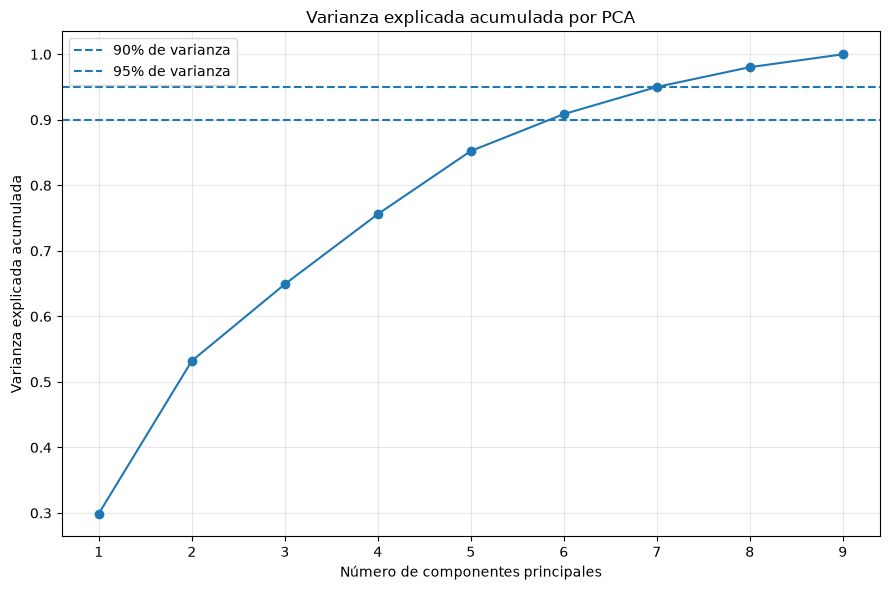

In [11]:
plt.figure(figsize=(9, 6))

components = range(
    1,
    len(pca_full.explained_variance_ratio_) + 1
)

plt.plot(
    components,
    variance_cumulative,
    marker="o"
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90% de varianza"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="95% de varianza"
)

plt.title("Varianza explicada acumulada por PCA")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.xticks(list(components))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "../figuras/pca_explained_variance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

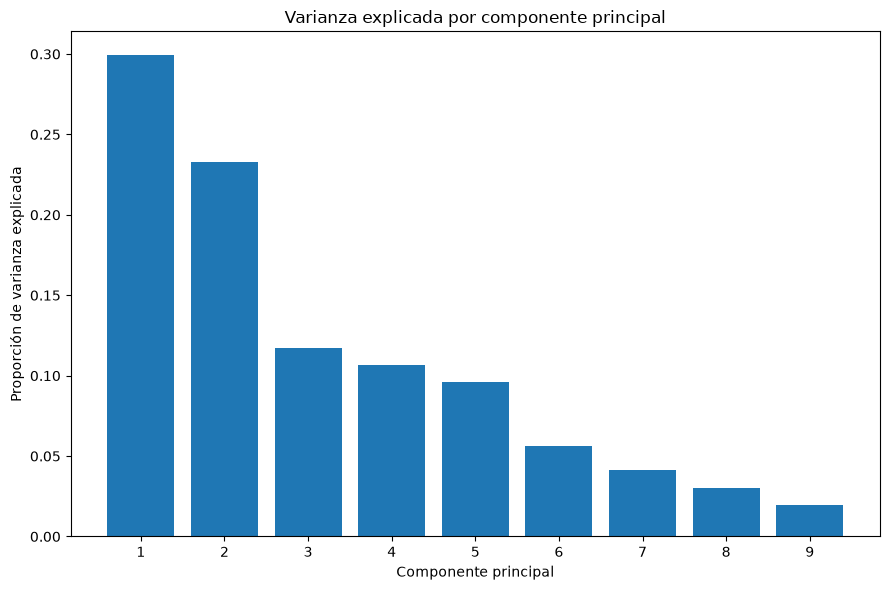

In [12]:
plt.figure(figsize=(9, 6))

plt.bar(
    components,
    pca_full.explained_variance_ratio_
)

plt.title("Varianza explicada por componente principal")
plt.xlabel("Componente principal")
plt.ylabel("Proporción de varianza explicada")
plt.xticks(list(components))
plt.tight_layout()

plt.savefig(
    "../figuras/pca_individual_variance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
df.shape

(202, 10)

In [14]:
df.isnull().sum()

ingresos          0
gastos_comunes    0
pago_coche        0
gastos_otros      0
ahorros           0
vivienda          0
estado_civil      0
hijos             0
trabajo           0
comprar           0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe()

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,4958.995050,971.584158,211.742574,515.425743,38749.668317,373349.638614,1.024752,1.232673,4.490099,0.331683
std,1682.862556,272.106351,124.940754,168.103075,17365.231870,136371.525622,0.837184,1.367833,2.535794,0.471988
min,2008.000000,384.000000,0.000000,201.000000,10319.000000,176553.000000,0.000000,0.000000,0.000000,0.000000
25%,3513.750000,766.750000,99.000000,383.250000,24964.250000,274810.000000,0.000000,0.000000,2.000000,0.000000
50%,4947.500000,968.000000,208.500000,522.500000,38523.000000,340783.500000,1.000000,1.000000,5.000000,0.000000
75%,6374.500000,1165.250000,318.750000,656.750000,52150.750000,444482.000000,2.000000,2.000000,7.000000,1.000000
max,7984.000000,1585.000000,448.000000,828.000000,69934.000000,669540.000000,2.000000,4.000000,8.000000,1.000000


In [17]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

print("Forma después de PCA:", X_pca_full.shape)

Forma después de PCA: (202, 9)


In [18]:
print("Varianza explicada por componente:")

for i, variance in enumerate(
    pca_full.explained_variance_ratio_,
    start=1
):
    print(f"PC{i}: {variance:.4f}")

Varianza explicada por componente:
PC1: 0.2991
PC2: 0.2329
PC3: 0.1171
PC4: 0.1069
PC5: 0.0964
PC6: 0.0563
PC7: 0.0415
PC8: 0.0302
PC9: 0.0197


In [19]:
variance_cumulative = np.cumsum(
    pca_full.explained_variance_ratio_
)

print("\nVarianza explicada acumulada:")

for i, variance in enumerate(
    variance_cumulative,
    start=1
):
    print(f"PC{i}: {variance:.4f}")


Varianza explicada acumulada:
PC1: 0.2991
PC2: 0.5321
PC3: 0.6492
PC4: 0.7561
PC5: 0.8524
PC6: 0.9087
PC7: 0.9502
PC8: 0.9803
PC9: 1.0000


In [20]:
componentes = range(1, 10)

resultados_pca = []

for n in componentes:
    pca = PCA(n_components=n)
    pca.fit(X_scaled)
    
    varianza_acumulada = pca.explained_variance_ratio_.sum()
    
    resultados_pca.append({
        "Componentes": n,
        "Varianza explicada": varianza_acumulada
    })

resultados_pca = pd.DataFrame(resultados_pca)

resultados_pca

,Componentes,Varianza explicada
0,1,0.299136
1,2,0.532085
2,3,0.649197
3,4,0.756053
4,5,0.852406
5,6,0.908705
6,7,0.950161
7,8,0.980339
8,9,1.000000


In [21]:
for threshold in [0.90, 0.95, 0.99]:
    n_componentes = np.argmax(
        variance_cumulative >= threshold
    ) + 1
    
    print(
        f"Componentes necesarios para {threshold*100:.0f}% "
        f"de varianza: {n_componentes}"
    )

Componentes necesarios para 90% de varianza: 6
Componentes necesarios para 95% de varianza: 7
Componentes necesarios para 99% de varianza: 9


In [22]:
pca_final = PCA(n_components=7)

X_pca = pca_final.fit_transform(X_scaled)

print("Dimensiones originales:", X.shape)
print("Dimensiones después de PCA:", X_pca.shape)

print(
    f"Varianza explicada por los 7 componentes: "
    f"{pca_final.explained_variance_ratio_.sum():.4f}"
)

Dimensiones originales: (202, 9)
Dimensiones después de PCA: (202, 7)
Varianza explicada por los 7 componentes: 0.9502


In [23]:
component_names = [
    f"PC{i}"
    for i in range(1, 8)
]

loadings = pd.DataFrame(
    pca_final.components_.T,
    index=X.columns,
    columns=component_names
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
ingresos,0.493720,0.306959,-0.091419,0.111222,0.088897,-0.075477,-0.154319
gastos_comunes,0.318229,0.147373,-0.363453,0.081630,0.763006,0.067903,0.105598
pago_coche,-0.123771,-0.091641,-0.516144,0.780268,-0.265554,-0.153697,-0.027333
gastos_otros,-0.111876,0.000112,0.701986,0.590704,0.330744,0.154422,-0.101876
ahorros,0.444650,0.288435,0.191767,0.022839,-0.289002,-0.230181,-0.524584
vivienda,0.462609,0.148985,0.140513,0.150085,-0.365556,0.290799,0.641034
estado_civil,-0.252279,0.469044,-0.172885,-0.007663,-0.104639,0.767070,-0.212365
hijos,-0.259859,0.521894,0.112184,0.007404,0.043668,-0.387964,0.460067
trabajo,-0.290248,0.527156,-0.036910,-0.007493,0.000009,-0.256446,-0.105053


In [24]:
for component in component_names:
    print(f"\n{component}:")
    
    top_variables = (
        loadings[component]
        .abs()
        .sort_values(ascending=False)
        .head(3)
    )
    
    for variable in top_variables.index:
        print(
            f"  {variable}: "
            f"{loadings.loc[variable, component]:.4f}"
        )


PC1:
  ingresos: 0.4937
  vivienda: 0.4626
  ahorros: 0.4447

PC2:
  trabajo: 0.5272
  hijos: 0.5219
  estado_civil: 0.4690

PC3:
  gastos_otros: 0.7020
  pago_coche: -0.5161
  gastos_comunes: -0.3635

PC4:
  pago_coche: 0.7803
  gastos_otros: 0.5907
  vivienda: 0.1501

PC5:
  gastos_comunes: 0.7630
  vivienda: -0.3656
  gastos_otros: 0.3307

PC6:
  estado_civil: 0.7671
  hijos: -0.3880
  vivienda: 0.2908

PC7:
  vivienda: 0.6410
  ahorros: -0.5246
  hijos: 0.4601


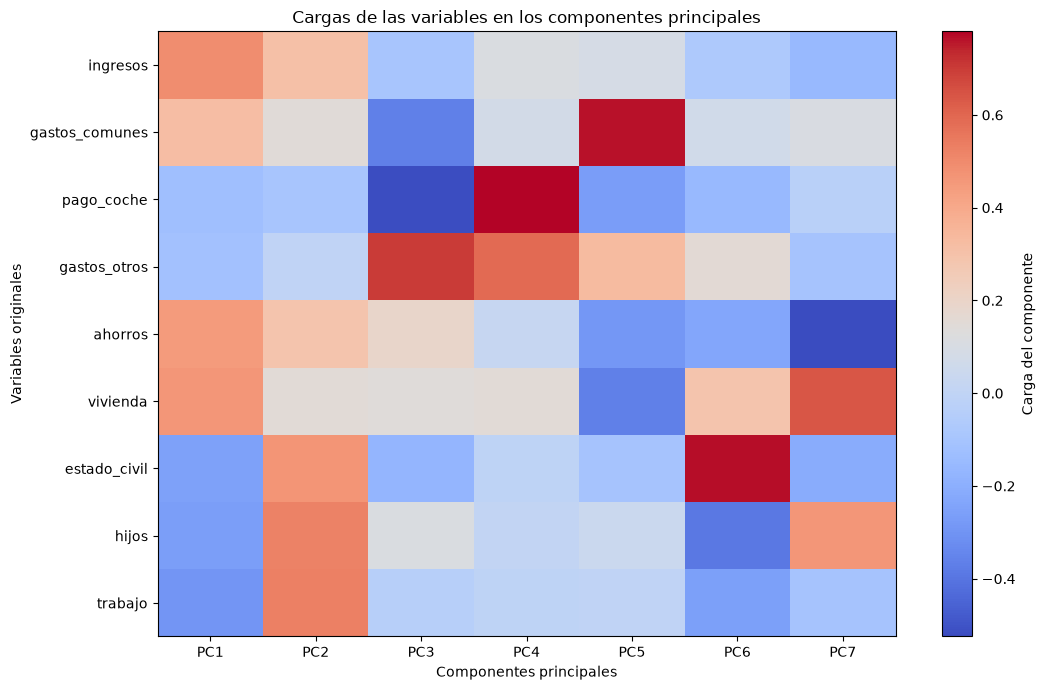

In [25]:
plt.figure(figsize=(11, 7))

plt.imshow(
    loadings,
    aspect="auto",
    cmap="coolwarm"
)

plt.colorbar(label="Carga del componente")

plt.xticks(
    range(len(component_names)),
    component_names
)

plt.yticks(
    range(len(X.columns)),
    X.columns
)

plt.title("Cargas de las variables en los componentes principales")
plt.xlabel("Componentes principales")
plt.ylabel("Variables originales")

plt.tight_layout()

plt.savefig(
    "../figuras/pca_loadings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

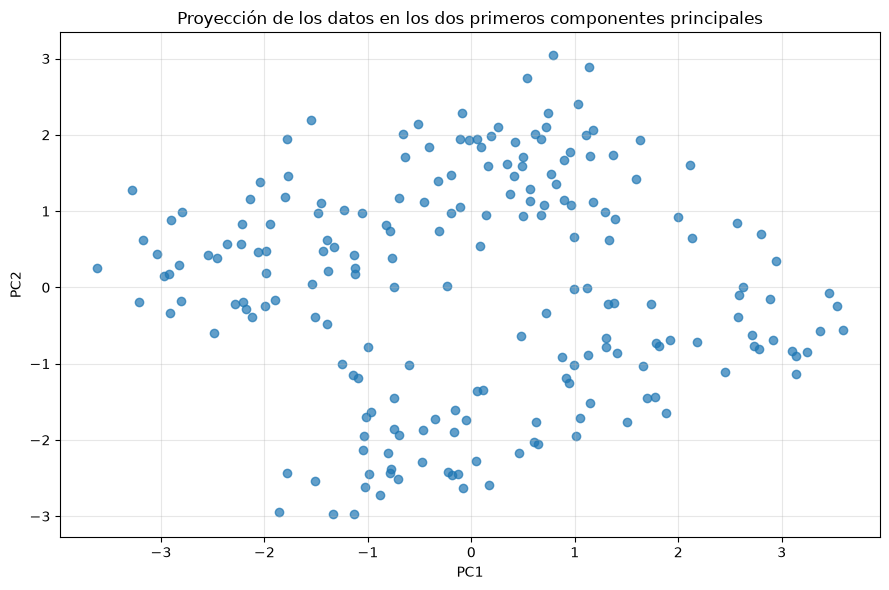

In [26]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.7
)

plt.title("Proyección de los datos en los dos primeros componentes principales")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figuras/pca_projection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

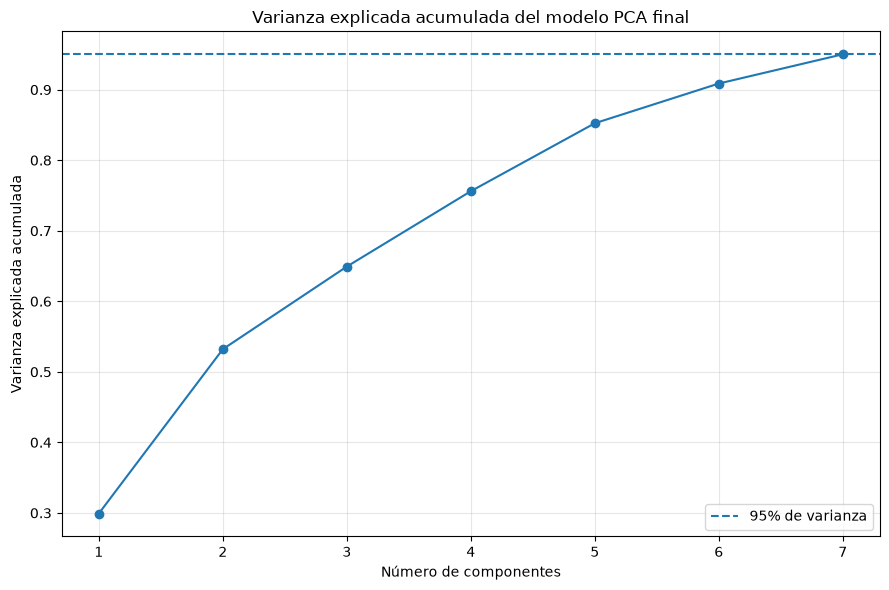

In [27]:
plt.figure(figsize=(9, 6))

componentes_finales = range(
    1,
    len(pca_final.explained_variance_ratio_) + 1
)

varianza_final = np.cumsum(
    pca_final.explained_variance_ratio_
)

plt.plot(
    componentes_finales,
    varianza_final,
    marker="o"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="95% de varianza"
)

plt.title("Varianza explicada acumulada del modelo PCA final")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.xticks(list(componentes_finales))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "../figuras/pca_final_variance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
import joblib
from sklearn.pipeline import Pipeline

pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=7))
])

pca_pipeline.fit(X)

print("Pipeline PCA entrenado correctamente.")

Pipeline PCA entrenado correctamente.


In [31]:
joblib.dump(
    pca_pipeline,
    "../models/dimensionality_reduction/comprar_alquilar_pca.joblib"
)

print(
    "Modelo guardado correctamente en "
    "../models/dimensionality_reduction/comprar_alquilar_pca.joblib"
)

Modelo guardado correctamente en ../models/dimensionality_reduction/comprar_alquilar_pca.joblib


In [32]:
modelo_cargado = joblib.load(
    "../models/dimensionality_reduction/comprar_alquilar_pca.joblib"
)

print("Modelo cargado correctamente.")

X_transformado = modelo_cargado.transform(X)

print(
    "Forma de los datos transformados:",
    X_transformado.shape
)

Modelo cargado correctamente.
Forma de los datos transformados: (202, 7)


In [33]:
loadings.to_csv(
    "../models/dimensionality_reduction/pca_loadings.csv"
)

print("Cargas guardadas correctamente.")

Cargas guardadas correctamente.
